### **Plotting Image**

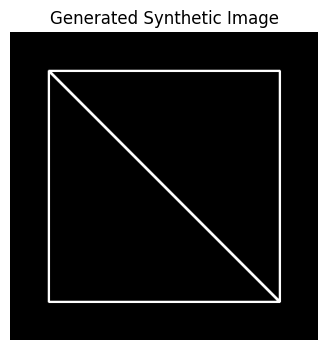

In [6]:
# Importing required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Generate a blank image
image_height, image_width = 400, 400
image = np.zeros((image_height, image_width), dtype=np.uint8)

# Draw white lines on the black background
cv2.line(image, (50, 50), (350, 50), 255, 2)  # Horizontal line
cv2.line(image, (50, 50), (50, 350), 255, 2)  # Vertical line
cv2.line(image, (50, 350), (350, 350), 255, 2)  # Another horizontal line
cv2.line(image, (350, 50), (350, 350), 255, 2)  # Another vertical line
cv2.line(image, (50, 50), (350, 350), 255, 2)  # Diagonal line

# Display the generated synthetic image
plt.figure(figsize=(6, 4))
plt.imshow(image, cmap='gray')
plt.title("Generated Synthetic Image")
plt.axis('off')
plt.show()


### **Preprocessing (Edge Detection)**

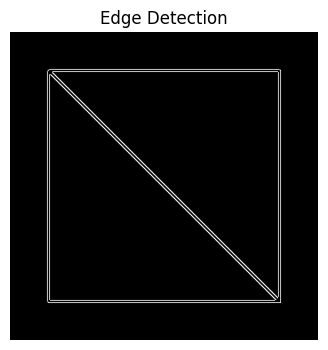

In [5]:
# Apply Canny Edge Detection
edges = cv2.Canny(image, threshold1=50, threshold2=150)

# Display the edge-detected image
plt.figure(figsize=(6, 4))
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis('off')
plt.show()


### **Applying Hough Transform and Visualizing Results**

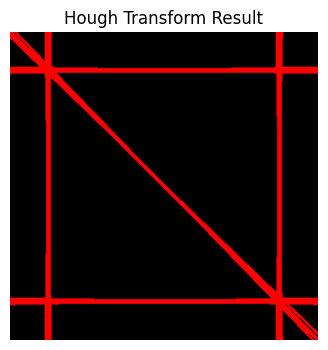

In [4]:
# Perform Hough Line Transform
lines = cv2.HoughLines(edges, rho=1, theta=np.pi / 180, threshold=100)

# Create a copy of the original image to draw the lines
color_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

# Draw the detected lines on the image
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(color_image, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Display the result
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title("Hough Transform Result")
plt.axis('off')
plt.show()


## **Implementation from Scratch**

In [10]:
def hough_transform(image, theta_res=1, rho_res=1):
    """
    Implement the Hough Transform from scratch for line detection.
    
    Parameters:
    - image: Binary image (edges)
    - theta_res: Resolution of theta in degrees
    - rho_res: Resolution of rho in pixels
    
    Returns:
    - accumulator: The Hough accumulator matrix
    - thetas: Array of theta values
    - rhos: Array of rho values
    """
    # Image dimensions
    height, width = image.shape
    
    # Calculate diagonal length - maximum possible distance
    diagonal_length = int(np.ceil(np.sqrt(height**2 + width**2)))
    
    # Define the range of rho and theta
    thetas = np.deg2rad(np.arange(0, 180, theta_res))
    rhos = np.arange(-diagonal_length, diagonal_length + 1, rho_res)
    
    # Initialize the accumulator
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
    
    # Find edge points
    y_idxs, x_idxs = np.nonzero(image)
    
    # For each edge point, calculate rho for each theta and vote in accumulator
    for i in range(len(y_idxs)):
        y = y_idxs[i]
        x = x_idxs[i]
        
        for theta_idx, theta in enumerate(thetas):
            # Calculate rho = x*cos(theta) + y*sin(theta)
            rho = int(round(x * np.cos(theta) + y * np.sin(theta)))
            
            # Find the corresponding index in rhos array
            rho_idx = np.where(rhos == rho)[0]
            
            if len(rho_idx) > 0:
                accumulator[rho_idx[0], theta_idx] += 1
    
    return accumulator, thetas, rhos

### **Line Detection**

In [ ]:
def detect_lines(accumulator, thetas, rhos, threshold):
    """
    Detect lines from the Hough accumulator by finding peaks.
    
    Parameters:
    - accumulator: The Hough accumulator matrix
    - thetas: Array of theta values
    - rhos: Array of rho values
    - threshold: Minimum number of votes to be considered a line
    
    Returns:
    - lines: List of (rho, theta) pairs representing detected lines
    """
    lines = []
    for rho_idx in range(accumulator.shape[0]):
        for theta_idx in range(accumulator.shape[1]):
            if accumulator[rho_idx, theta_idx] > threshold:
                lines.append((rhos[rho_idx], thetas[theta_idx]))
    return lines

### **Draw Lines**

In [12]:
def draw_lines(image, lines):
    """
    Draw detected lines on the original image.
    
    Parameters:
    - image: Original image
    - lines: List of (rho, theta) pairs
    
    Returns:
    - result_image: Image with lines drawn
    """
    result_image = np.copy(image)
    if len(image.shape) == 2:
        # Convert to RGB if it's grayscale
        result_image = np.dstack((result_image, result_image, result_image))
    
    height, width = image.shape[:2]
    
    for rho, theta in lines:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        
        # Calculate endpoint coordinates for line segment
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        
        # Draw the line
        cv2.line(result_image, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
    return result_image

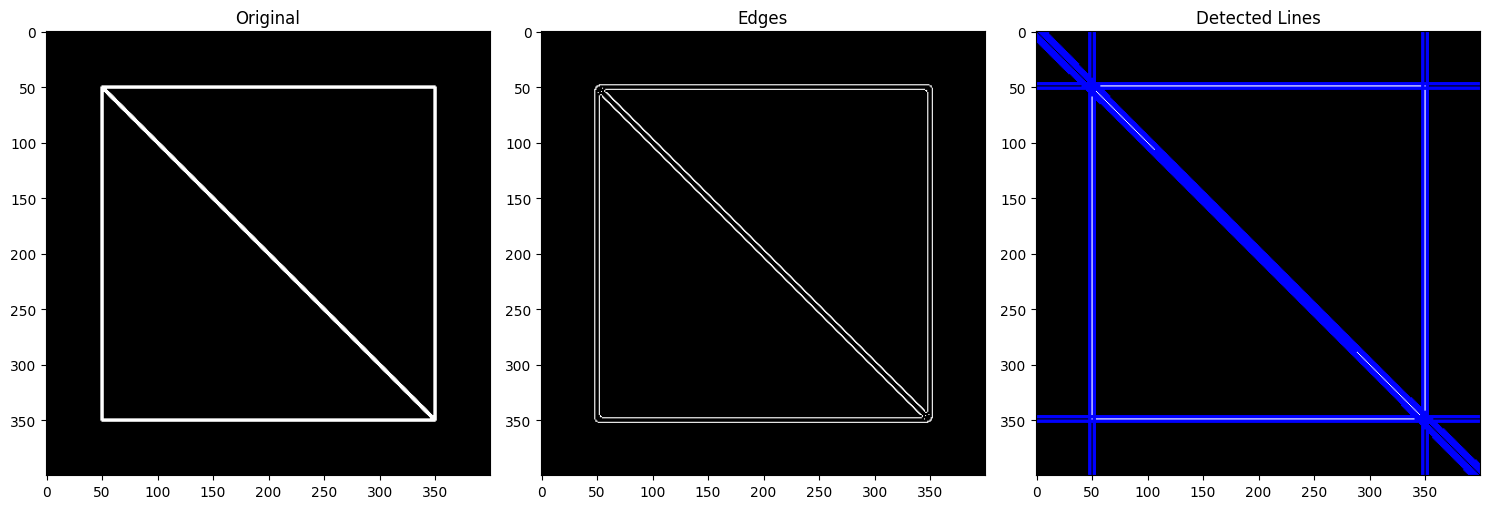

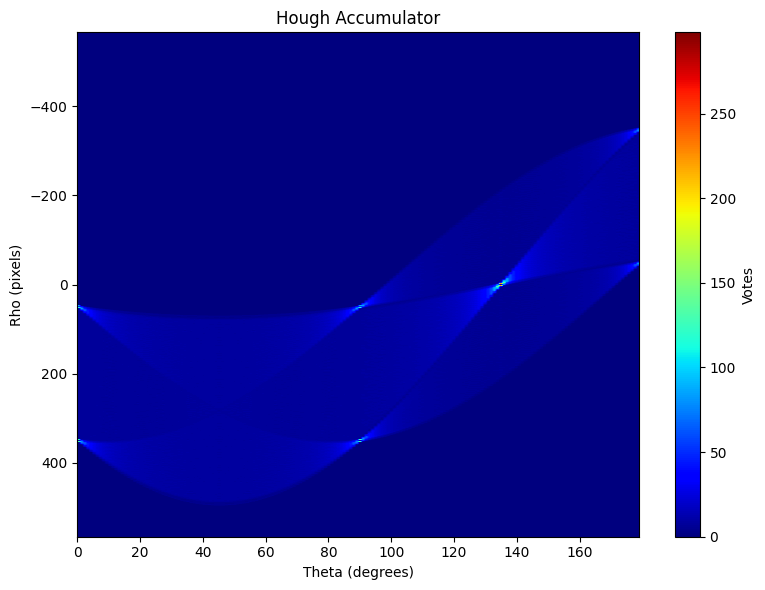

In [15]:
# Example usage with a sample image
def example_usage():
    # You would need these imports for a complete working example
    import cv2
    from skimage.feature import canny
        
    # Detect edges using Canny
    edges = canny(image, sigma=2)
    
    # Apply Hough Transform
    accumulator, thetas, rhos = hough_transform(edges)
    
    # Find lines with at least 100 votes
    lines = detect_lines(accumulator, thetas, rhos, threshold=100)
    
    # Draw lines on the original image
    result = draw_lines(image, lines)
    
    # Display results
    plt.figure(figsize=(15, 8))
    plt.subplot(131), plt.imshow(image, cmap='gray'), plt.title('Original')
    plt.subplot(132), plt.imshow(edges, cmap='gray'), plt.title('Edges')
    plt.subplot(133), plt.imshow(result), plt.title('Detected Lines')
    plt.tight_layout()
    plt.show()
    
    # Display the Hough accumulator space
    plt.figure(figsize=(8, 6))
    plt.imshow(accumulator, cmap='jet', aspect='auto',
               extent=[np.rad2deg(thetas[0]), np.rad2deg(thetas[-1]), rhos[-1], rhos[0]])
    plt.title('Hough Accumulator')
    plt.xlabel('Theta (degrees)')
    plt.ylabel('Rho (pixels)')
    plt.colorbar(label='Votes')
    plt.tight_layout()
    plt.show()

example_usage()